In [1]:
!pip install qiskit[visualization]
!pip install qiskit-aer
!pip install qiskit-ibm-runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 126.9 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=c4df2b2347a2d7bb9b2181e68e21bbf9888c142b9c1b07fb97c1505c2bcd4f8a
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.7/378.7 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [7]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Shor's 9-qubit code requires:
# 9 Data Qubits (q), 8 Ancilla Qubits (a), 8 Syndrome Bits (s), 9 Final Measure Bits (c)
q = QuantumRegister(9, 'data')
a1 = QuantumRegister(2, 'ancilla1')
a2 = QuantumRegister(2, 'ancilla2')
a3 = QuantumRegister(2, 'ancilla3')
a4 = QuantumRegister(2, 'ancilla4')
s1 = ClassicalRegister(2, 'syn_block1')
s2 = ClassicalRegister(2, 'syn_block2')
s3 = ClassicalRegister(2, 'syn_block3')
s4 = ClassicalRegister(2, 'syn_phase')
c = ClassicalRegister(9, 'measure')
qc = QuantumCircuit(q, a1, a2, a3, a4, s1, s2, s3, s4, c)

# --- 1. ENCODING ---
# qc.x(q[0])
# qc.barrier()
# Phase Flip Encoding (Outer Code)
qc.cx(q[0], q[3])
qc.cx(q[0], q[6])
qc.h(q[0])
qc.h(q[3])
qc.h(q[6])

# Bit Flip Encoding (Inner Code)
qc.cx(q[0], q[1])
qc.cx(q[3], q[4])
qc.cx(q[6], q[7])
qc.cx(q[0], q[2])
qc.cx(q[3], q[5])
qc.cx(q[6], q[8])

qc.barrier()

# INSERT ERROR HERE ---
qc.x(q[5])
qc.z(q[5])
qc.barrier()

# --- 2. SYNDROME MEASUREMENT (PARITY CHECKS) ---

# Bit-flip checks (Z-parity) for each block of 3
# Block 1: Checks (0,1) and (1,2)
qc.cx(q[0], a1[0])
qc.cx(q[1], a1[0])
qc.cx(q[1], a1[1])
qc.cx(q[2], a1[1])

# Block 2: Checks (3,4) and (4,5)
qc.cx(q[3], a2[0])
qc.cx(q[4], a2[0])
qc.cx(q[4], a2[1])
qc.cx(q[5], a2[1])

# Block 3: Checks (6,7) and (7,8)
qc.cx(q[6], a3[0])
qc.cx(q[7], a3[0])
qc.cx(q[7], a3[1])
qc.cx(q[8], a3[1])

qc.barrier()
# Measure syndromes to detect bit flip error location
qc.measure(a1, s1)
qc.measure(a2, s2)
qc.measure(a3, s3)

qc.barrier()

#BIT FLIP error correction
qc.x(q[5])
qc.barrier()

# Phase-flip checks (X-parity) across blocks

qc.h(q)

qc.cx(q[0], a4[0])
# qc.h(q[0])
qc.cx(q[1], a4[0])
# qc.h(q[1])
qc.cx(q[2], a4[0])
# qc.h(q[2])
qc.cx(q[3], a4[0])
qc.cx(q[4], a4[0])
qc.cx(q[5], a4[0])
qc.cx(q[3], a4[1])
# qc.h(q[3])
qc.cx(q[4], a4[1])
# qc.h(q[4])
qc.cx(q[5], a4[1])
# qc.h(q[5])
qc.cx(q[6], a4[1])
# qc.h(q[6])
qc.cx(q[7], a4[1])
# qc.h(q[7])
qc.cx(q[8], a4[1])
# qc.h(q[8])

qc.barrier()
qc.h(q)

qc.measure(a4, s4)

#PHASE FLIP error correction
qc.z(q[5])

qc.barrier()

#Decoding
# qc.h(q)
qc.cx(q[0], q[2])
qc.cx(q[3], q[5])
qc.cx(q[6], q[8])

qc.cx(q[0], q[1])
qc.cx(q[3], q[4])
qc.cx(q[6], q[7])

qc.h(q[0])
qc.h(q[3])
qc.h(q[6])

qc.cx(q[0], q[6])
qc.cx(q[0], q[3])

qc.barrier()

# Final measurement of data qubits
qc.measure(q, c)

sim = AerSimulator()
counts = sim.run(qc).result().get_counts()


print("\nShor code with bit flip and phase error")
print("----------------------------------------")
print(counts)



Shor code with bit flip and phase error
----------------------------------------
{'000000000 11 00 10 00': 1024}


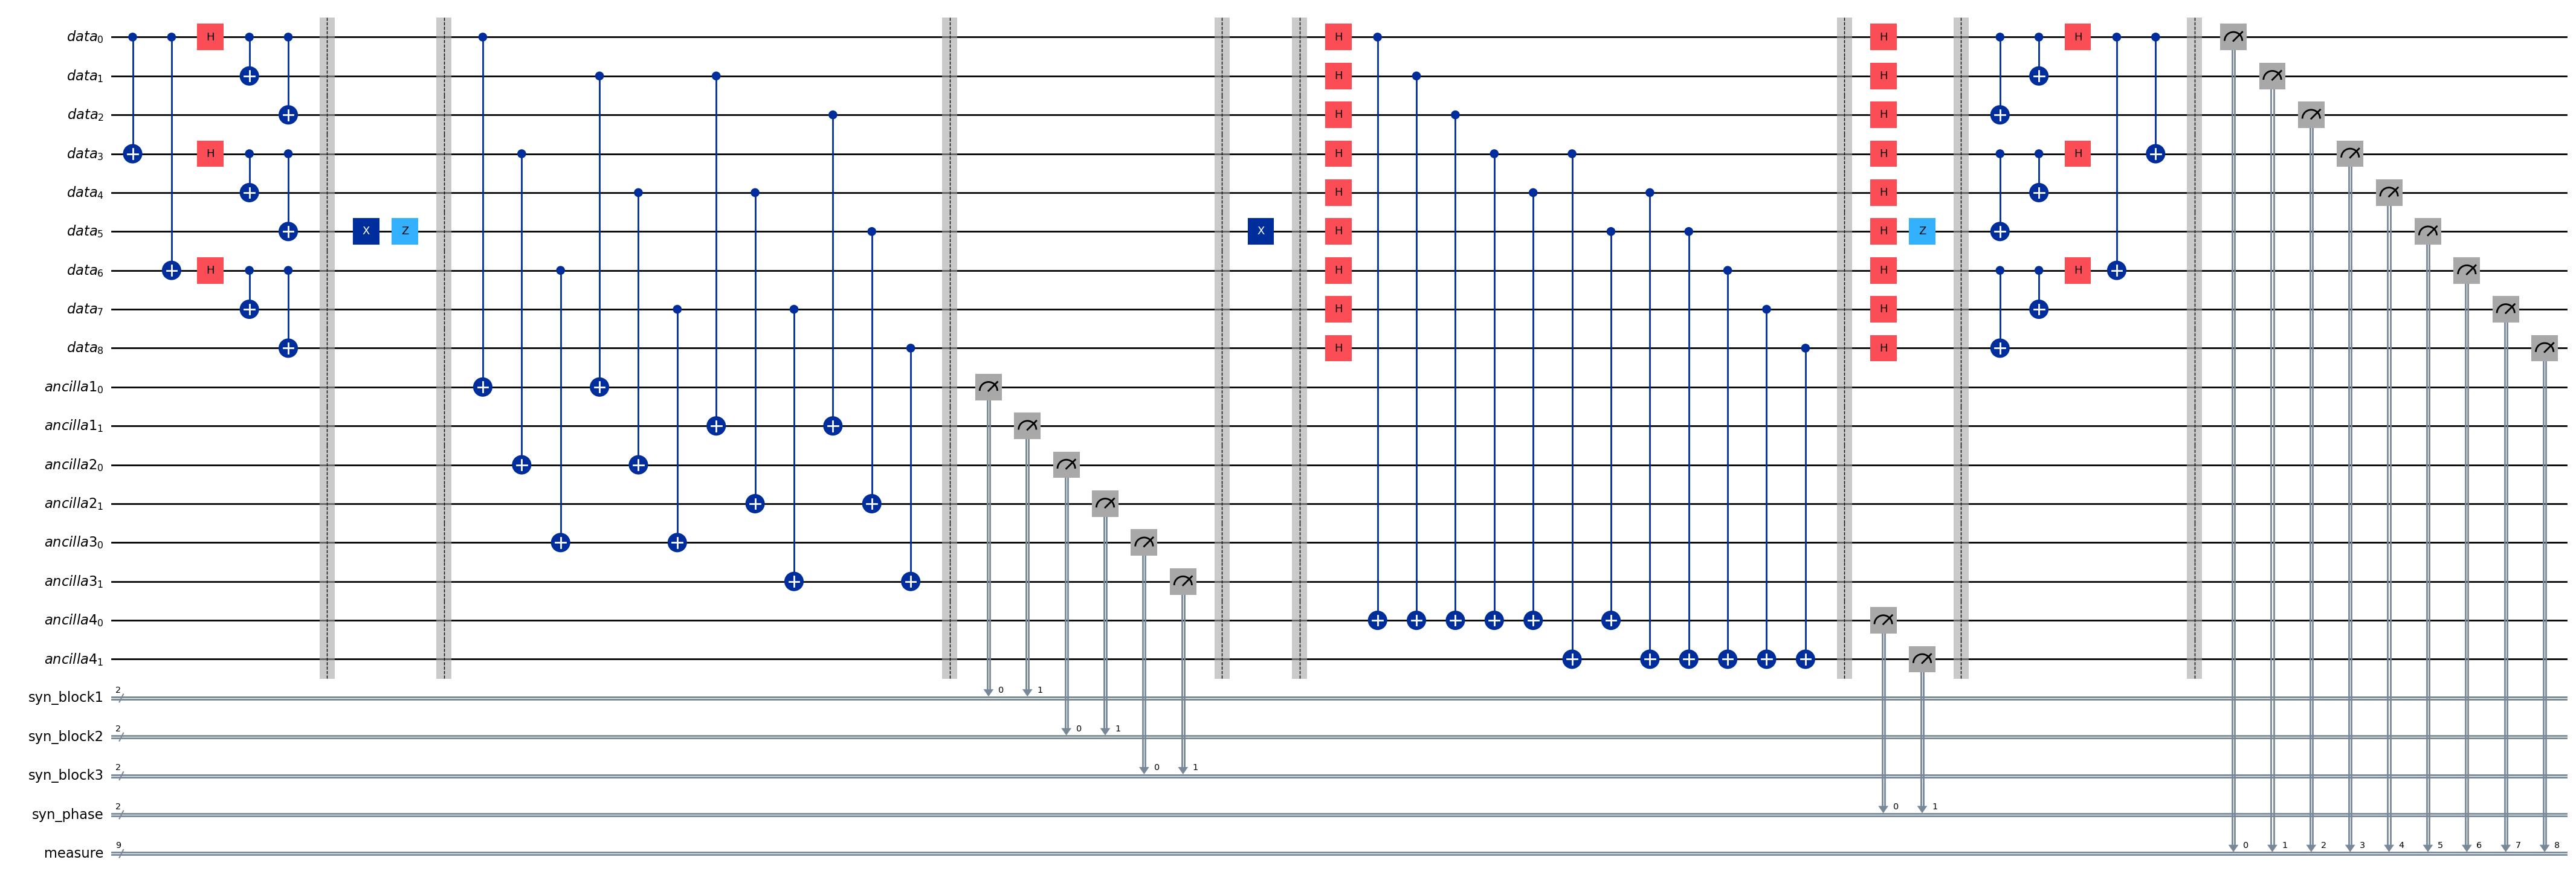

In [8]:
qc.draw(output="mpl", fold=1)

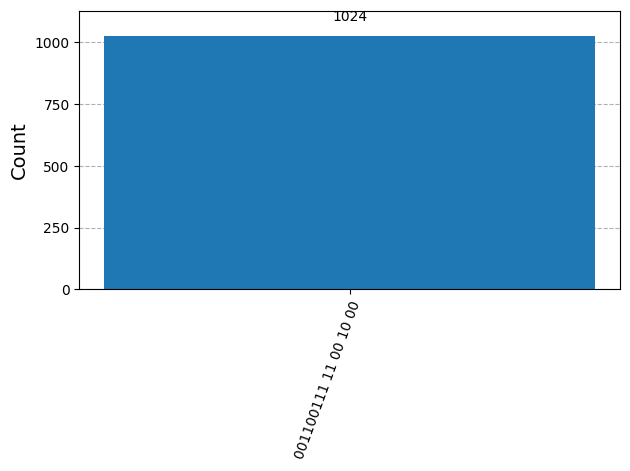

In [4]:
plot_histogram(counts)